Montando drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Importando as dependências

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score


Carregando o arquivo e visualizando os dados

In [3]:
dataADT = pd.read_csv('drive/MyDrive/TEES/Autism_Dataset_for_Toddlers.csv')
dataADT.head()

,Case_No,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age_Mons,Qchat-10-Score,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who completed the test,Class/ASD Traits
0,1,0,0,0,0,0,0,1,1,0,1,28,3,f,middle eastern,yes,no,family member,No
1,2,1,1,0,0,0,1,1,0,0,0,36,4,m,White European,yes,no,family member,Yes
2,3,1,0,0,0,0,0,1,1,0,1,36,4,m,middle eastern,yes,no,family member,Yes
3,4,1,1,1,1,1,1,1,1,1,1,24,10,m,Hispanic,no,no,family member,Yes
4,5,1,1,0,1,1,1,1,1,1,1,20,9,f,White European,no,yes,family member,Yes


In [4]:
dataADT.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1054 entries, 0 to 1053
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Case_No                 1054 non-null   int64 
 1   A1                      1054 non-null   int64 
 2   A2                      1054 non-null   int64 
 3   A3                      1054 non-null   int64 
 4   A4                      1054 non-null   int64 
 5   A5                      1054 non-null   int64 
 6   A6                      1054 non-null   int64 
 7   A7                      1054 non-null   int64 
 8   A8                      1054 non-null   int64 
 9   A9                      1054 non-null   int64 
 10  A10                     1054 non-null   int64 
 11  Age_Mons                1054 non-null   int64 
 12  Qchat-10-Score          1054 non-null   int64 
 13  Sex                     1054 non-null   object
 14  Ethnicity               1054 non-null   object
 15  Jaun

Verificação de dados nulos

In [5]:
dataADT.isna().sum()

,0
Case_No,0
A1,0
A2,0
A3,0
A4,0
A5,0
A6,0
A7,0
A8,0
A9,0


Cenverter tipo da instância

In [6]:
le = LabelEncoder()
colToConvert = [
    'Class/ASD Traits ',
    'Jaundice',
    'Sex',
    'Family_mem_with_ASD'
]

for colum in colToConvert:
    dataADT[colum] = le.fit_transform(dataADT[colum])
    print(dataADT[colum].value_counts())
    print("-" * 40)

Class/ASD Traits 
1    728
0    326
Name: count, dtype: int64
----------------------------------------
Jaundice
0    766
1    288
Name: count, dtype: int64
----------------------------------------
Sex
1    735
0    319
Name: count, dtype: int64
----------------------------------------
Family_mem_with_ASD
0    884
1    170
Name: count, dtype: int64
----------------------------------------


Avaliação do modelo

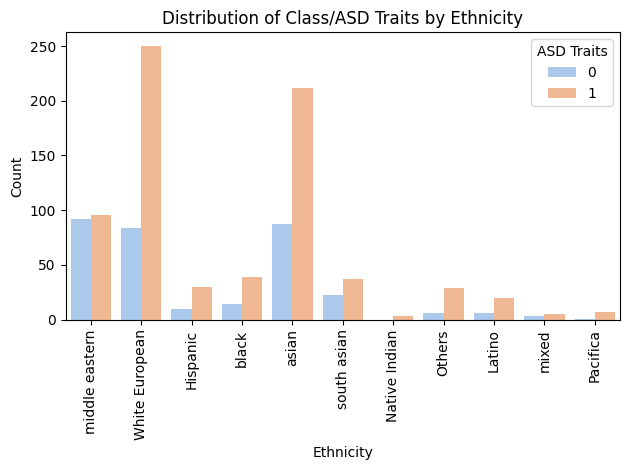

In [7]:
sns.countplot(data=dataADT, x='Ethnicity', hue='Class/ASD Traits ', palette='pastel')
plt.title('Distribution of Class/ASD Traits by Ethnicity')
plt.xlabel('Ethnicity')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend(title='ASD Traits', loc='upper right')
plt.tight_layout()
plt.show()

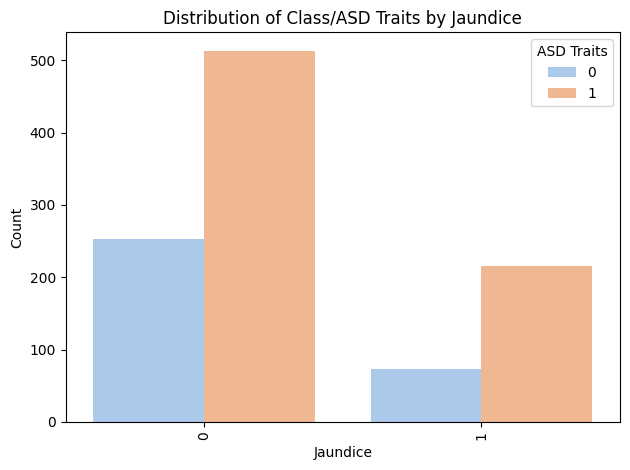

In [8]:
sns.countplot(data=dataADT, x='Jaundice', hue='Class/ASD Traits ', palette='pastel')
plt.title('Distribution of Class/ASD Traits by Jaundice')
plt.xlabel('Jaundice')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend(title='ASD Traits', loc='upper right')
plt.tight_layout()
plt.show()

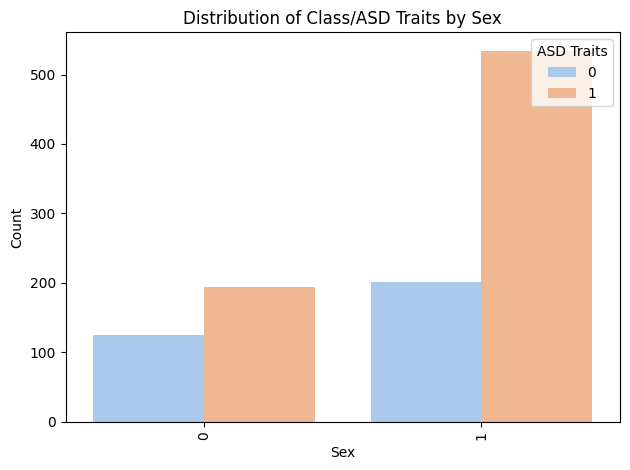

In [9]:
sns.countplot(data=dataADT, x='Sex', hue='Class/ASD Traits ', palette='pastel')
plt.title('Distribution of Class/ASD Traits by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend(title='ASD Traits', loc='upper right')
plt.tight_layout()
plt.show()

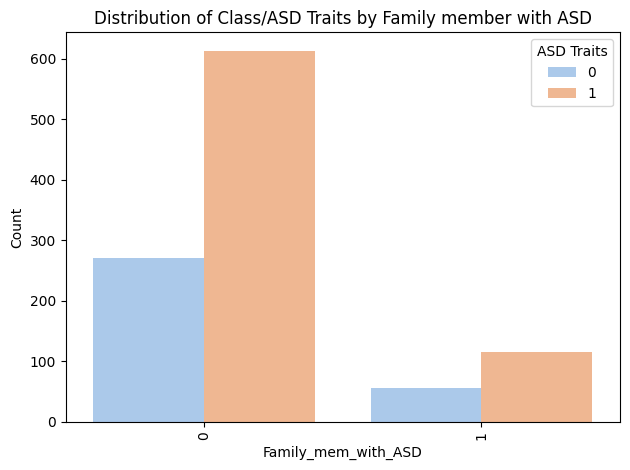

In [10]:
sns.countplot(data=dataADT, x='Family_mem_with_ASD', hue='Class/ASD Traits ', palette='pastel')
plt.title('Distribution of Class/ASD Traits by Family member with ASD')
plt.xlabel('Family_mem_with_ASD')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend(title='ASD Traits', loc='upper right')
plt.tight_layout()
plt.show()

Boxplot

<Axes: >

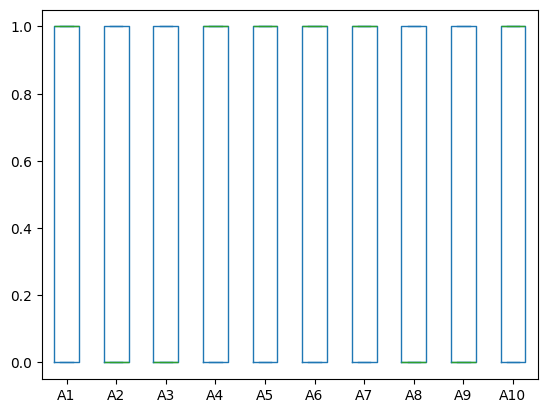

In [11]:
#separar em duas (caracteristicas comportamentais e caracteristicas individuais)
colBC = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10']
dataADT[colBC].plot(kind = 'box')

<Axes: >

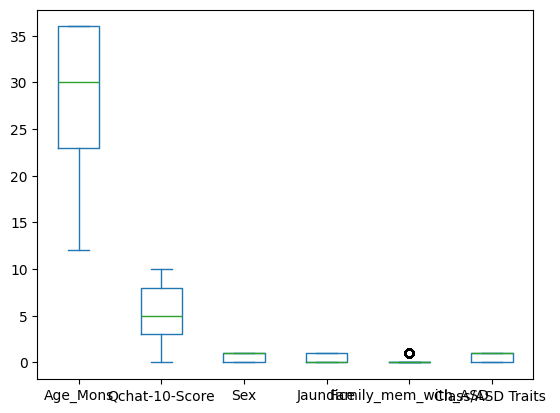

In [12]:
colIC = ['Age_Mons', 'Qchat-10-Score', 'Sex', 'Ethnicity', 'Jaundice', 'Family_mem_with_ASD', 'Who completed the test', 'Class/ASD Traits ']
dataADT[colIC].plot(kind = 'box')

In [13]:
#sns.pairplot(dataADT[colBC], kind='kde')

In [14]:
#sns.pairplot(dataADT[colIC], kind='kde')

In [15]:
dataADT['Ethnicity'] = le.fit_transform(dataADT['Ethnicity'])

In [16]:
dataADT['Who completed the test'] = le.fit_transform(dataADT['Who completed the test'])

In [17]:
dataADT['Sex'] = le.fit_transform(dataADT['Sex'])

In [18]:
dataADT['Jaundice'] = le.fit_transform(dataADT['Jaundice'])

In [19]:
dataADT['Class/ASD Traits '] = le.fit_transform(dataADT['Class/ASD Traits '])

In [20]:
dataADT['Family_mem_with_ASD'] = le.fit_transform(dataADT['Family_mem_with_ASD'])

Criando modelo

In [21]:
entry = dataADT.drop('Class/ASD Traits ', axis=1)
desired_output = dataADT['Class/ASD Traits '].values

data_train, data_test, output_train, output_test = train_test_split(entry, desired_output, test_size=0.2)

In [22]:
sc = StandardScaler()
sc.fit(data_train)

data_train_standardized = sc.transform(data_train)
data_test_standardized = sc.transform(data_test)

In [23]:
'''
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Dense(units=128, activation='relu', input_shape=(data_train.shape[1],)))
model.add(tf.keras.layers.Dense(units=64, activation='relu'))
model.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))
model.summary()
'''

"\nmodel = tf.keras.models.Sequential()\nmodel.add(tf.keras.layers.Dense(units=128, activation='relu', input_shape=(data_train.shape[1],)))\nmodel.add(tf.keras.layers.Dense(units=64, activation='relu'))\nmodel.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))\nmodel.summary()\n"

In [24]:
#model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

In [25]:
#historyADT = model.fit(data_train, output_train, epochs=60, batch_size=32, validation_split=0.2)

In [26]:
'''
plt.plot(historyADT.history['loss'], label='Train')
plt.plot(historyADT.history['val_loss'], label='Validation')
plt.title('Loss Function')
plt.xlabel('Accuracy')
plt.ylabel('Epochs')
plt.legend()
plt.yscale('log')
plt.grid(True)
plt.show()
'''

"\nplt.plot(historyADT.history['loss'], label='Train')\nplt.plot(historyADT.history['val_loss'], label='Validation')\nplt.title('Loss Function')\nplt.xlabel('Accuracy')\nplt.ylabel('Epochs')\nplt.legend()\nplt.yscale('log')\nplt.grid(True)\nplt.show()\n"

In [27]:
'''
output_pred = model.predict(data_test)

output_pred = output_pred.reshape(output_pred.shape[0])

output_pred = (output_pred > 0.5).astype(int)
'''

'\noutput_pred = model.predict(data_test)\n\noutput_pred = output_pred.reshape(output_pred.shape[0])\n\noutput_pred = (output_pred > 0.5).astype(int)\n'

<Axes: >

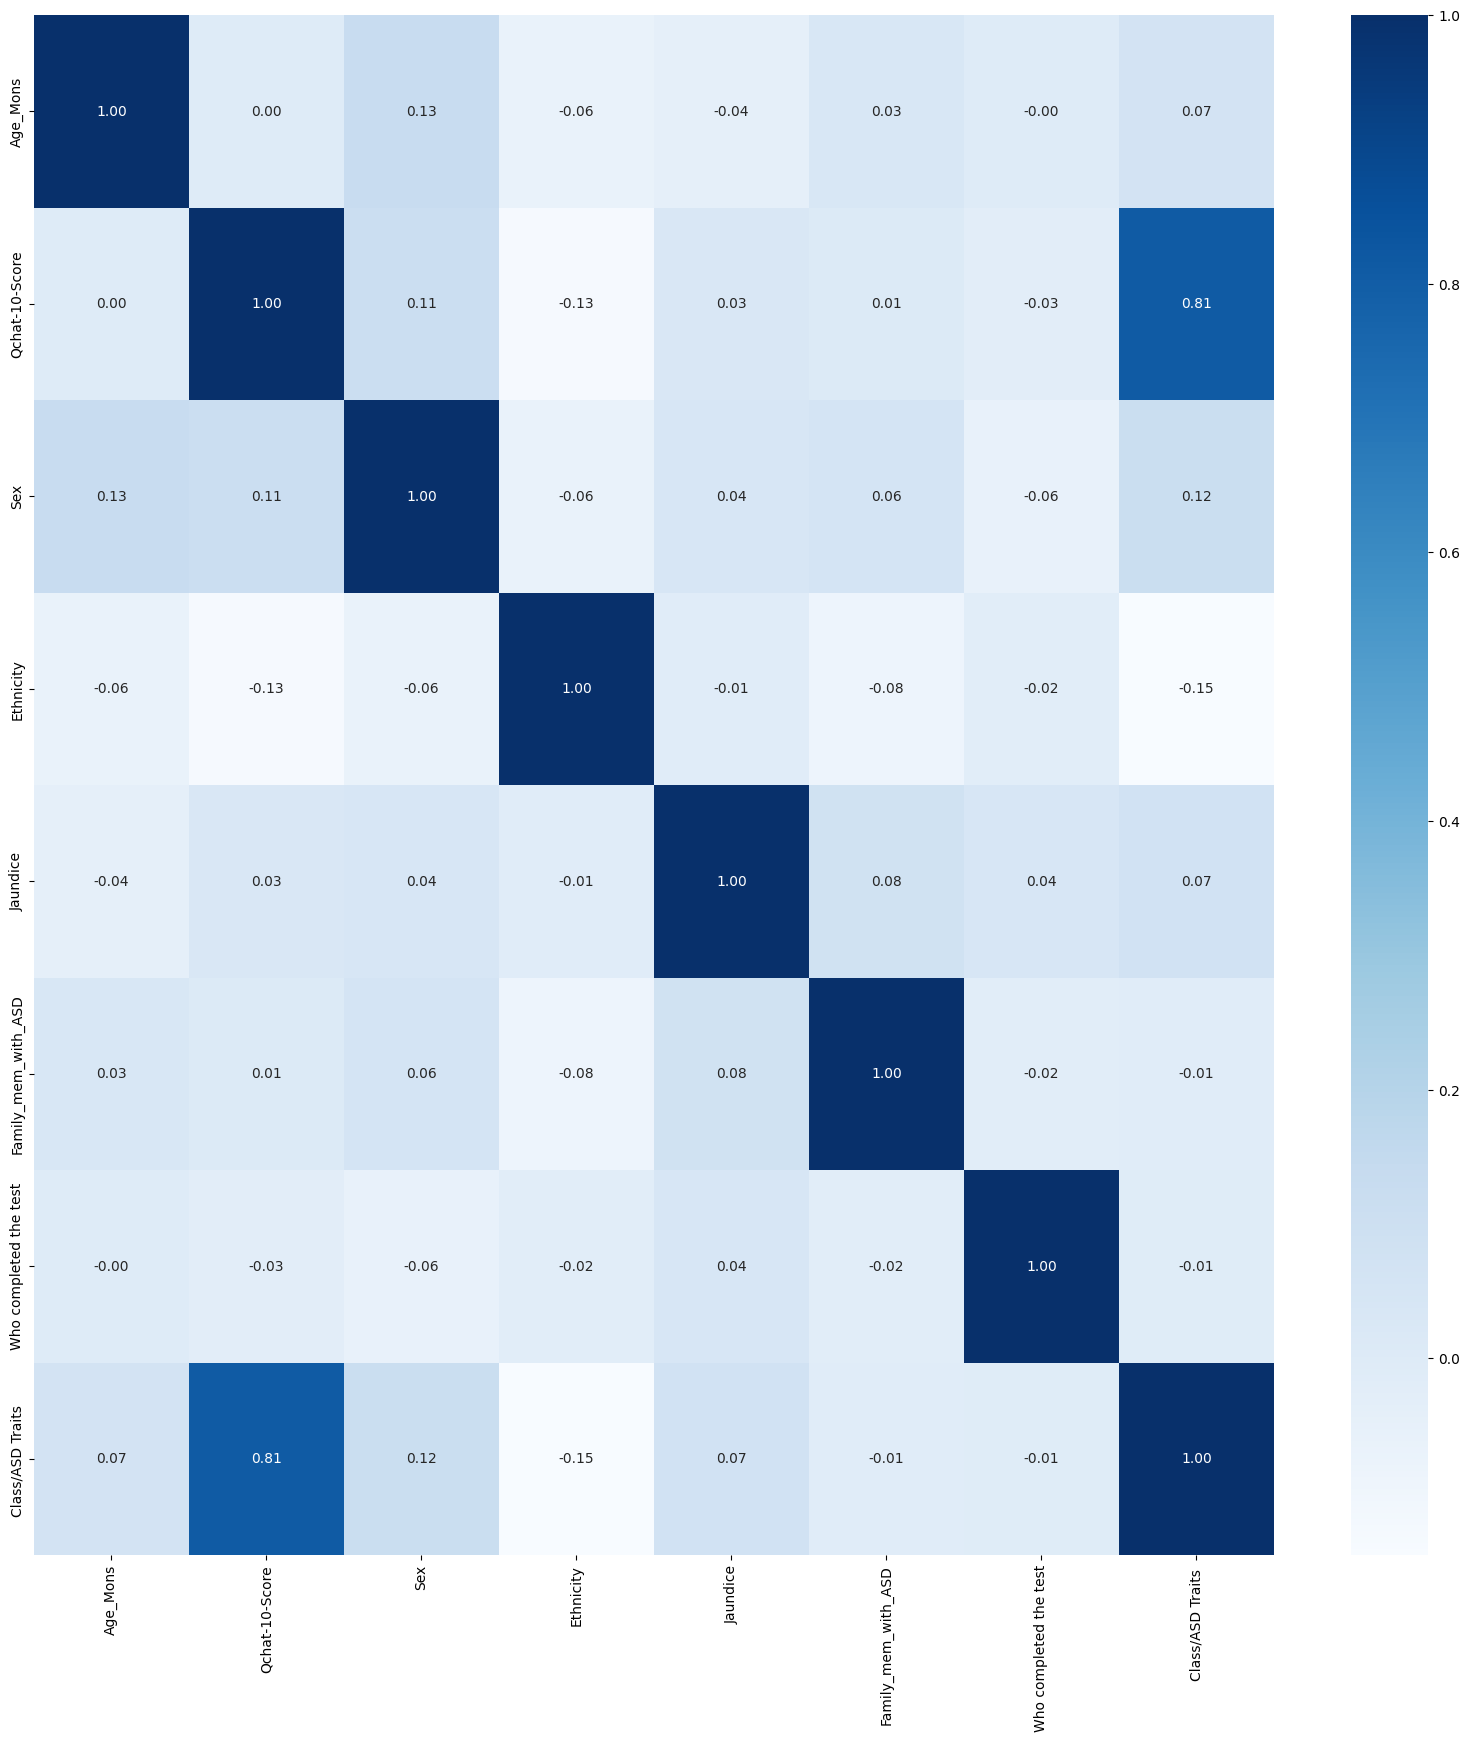

In [28]:
attributes = ['Age_Mons', 'Qchat-10-Score', 'Sex', 'Ethnicity', 'Jaundice', 'Family_mem_with_ASD', 'Who completed the test', 'Class/ASD Traits ']
corr = dataADT[attributes].corr()
plt.figure(figsize = (20,20))

sns.heatmap(corr, annot=True, fmt=".2f", cmap='Blues')

In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn import metrics

param_grid = {
    'hidden_layer_sizes': [(100, ), (7,)], #default e heurístico
    'activation': ['identity', 'logistic', 'tanh', 'relu'],
    'learning_rate_init': [0.001, 0.01, 0.1],
    'max_iter': [200, 1000, 5000]
}

grid = GridSearchCV(MLPClassifier(),param_grid, verbose = 3, scoring='f1')
grid.fit(data_train,output_train)

pred = grid.predict(data_test)
print(metrics.classification_report(output_test, pred))

Fitting 5 folds for each of 72 candidates, totalling 360 fits


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV 1/5] END activation=identity, hidden_layer_sizes=(100,), learning_rate_init=0.001, max_iter=200;, score=0.958 total time=   0.6s
[CV 2/5] END activation=identity, hidden_layer_sizes=(100,), learning_rate_init=0.001, max_iter=200;, score=0.983 total time=   0.4s
[CV 3/5] END activation=identity, hidden_layer_sizes=(100,), learning_rate_init=0.001, max_iter=200;, score=0.983 total time=   0.3s
[CV 4/5] END activation=identity, hidden_layer_sizes=(100,), learning_rate_init=0.001, max_iter=200;, score=0.979 total time=   0.5s
[CV 5/5] END activation=identity, hidden_layer_sizes=(100,), learning_rate_init=0.001, max_iter=200;, score=0.987 total time=   0.5s
[CV 1/5] END activation=identity, hidden_layer_sizes=(100,), learning_rate_init=0.001, max_iter=1000;, score=0.960 total time=   0.4s
[CV 2/5] END activation=identity, hidden_layer_sizes=(100,), learning_rate_init=0.001, max_iter=1000;, score=0.970 total time=   0.3s
[CV 3/5] END activation=identity, hidden_layer_sizes=(100,), learni

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV 1/5] END activation=identity, hidden_layer_sizes=(7,), learning_rate_init=0.001, max_iter=200;, score=0.983 total time=   0.3s


...

[CV 3/5] END activation=relu, hidden_layer_sizes=(7,), learning_rate_init=0.001, max_iter=200;, score=0.983 total time=   0.3s


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV 4/5] END activation=relu, hidden_layer_sizes=(7,), learning_rate_init=0.001, max_iter=200;, score=0.938 total time=   0.3s


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV 5/5] END activation=relu, hidden_layer_sizes=(7,), learning_rate_init=0.001, max_iter=200;, score=0.957 total time=   0.3s
[CV 1/5] END activation=relu, hidden_layer_sizes=(7,), learning_rate_init=0.001, max_iter=1000;, score=0.983 total time=   1.0s
[CV 2/5] END activation=relu, hidden_layer_sizes=(7,), learning_rate_init=0.001, max_iter=1000;, score=0.996 total time=   0.8s
[CV 3/5] END activation=relu, hidden_layer_sizes=(7,), learning_rate_init=0.001, max_iter=1000;, score=0.996 total time=   1.1s
[CV 4/5] END activation=relu, hidden_layer_sizes=(7,), learning_rate_init=0.001, max_iter=1000;, score=0.974 total time=   1.1s
[CV 5/5] END activation=relu, hidden_layer_sizes=(7,), learning_rate_init=0.001, max_iter=1000;, score=0.974 total time=   1.0s
[CV 1/5] END activation=relu, hidden_layer_sizes=(7,), learning_rate_init=0.001, max_iter=5000;, score=0.970 total time=   0.9s
[CV 2/5] END activation=relu, hidden_layer_sizes=(7,), learning_rate_init=0.001, max_iter=5000;, score=0.

In [30]:
param_grid =  {'criterion' : ['gini','entropy'], 'splitter' : ['best', 'random'], 'max_depth' : list(range(3, 15)), 'max_features' : ["auto", "sqrt", "log2"], }

grid = GridSearchCV(DecisionTreeClassifier(),param_grid,verbose=3, scoring='f1')
grid.fit(data_train, output_train)
grid_predictions = grid.predict(data_test)

print(metrics.classification_report(output_test, grid_predictions))

Fitting 5 folds for each of 144 candidates, totalling 720 fits
[CV 1/5] END criterion=gini, max_depth=3, max_features=auto, splitter=best;, score=nan total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=3, max_features=auto, splitter=best;, score=nan total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=3, max_features=auto, splitter=best;, score=nan total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=3, max_features=auto, splitter=best;, score=nan total time=   0.0s
[CV 5/5] END criterion=gini, max_depth=3, max_features=auto, splitter=best;, score=nan total time=   0.0s
[CV 1/5] END criterion=gini, max_depth=3, max_features=auto, splitter=random;, score=nan total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=3, max_features=auto, splitter=random;, score=nan total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=3, max_features=auto, splitter=random;, score=nan total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=3, max_features=auto, splitter=random;, scor

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning: 
240 fits failed out of a total of 720.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
240 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1145, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 638, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/util

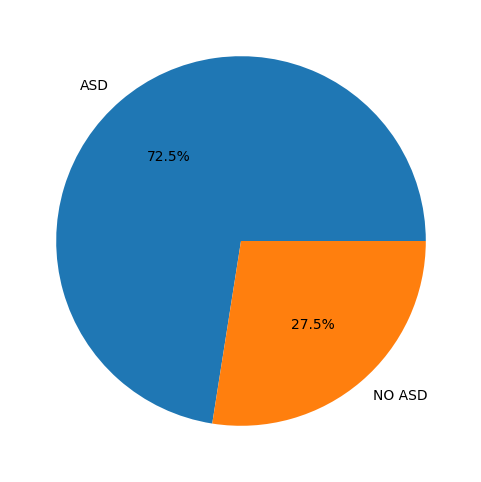

In [31]:
plt.figure(figsize=(11,6))
df2 = pd.DataFrame(grid_predictions, columns = ['Class/ASD Traits '])
sizes = df2['Class/ASD Traits '].value_counts()
labels = ['ASD', 'NO ASD']
plt.pie(sizes, labels = labels, autopct='%1.1f%%')


plt.show()

In [32]:
print(dataADT['Class/ASD Traits '].value_counts())


Class/ASD Traits 
1    728
0    326
Name: count, dtype: int64


In [33]:
data_train.shape

(843, 18)

In [34]:
pd.Series(output_train).value_counts()

,count
1,575
0,268
